In [2]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv('global_energy_mix.csv')

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))

Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


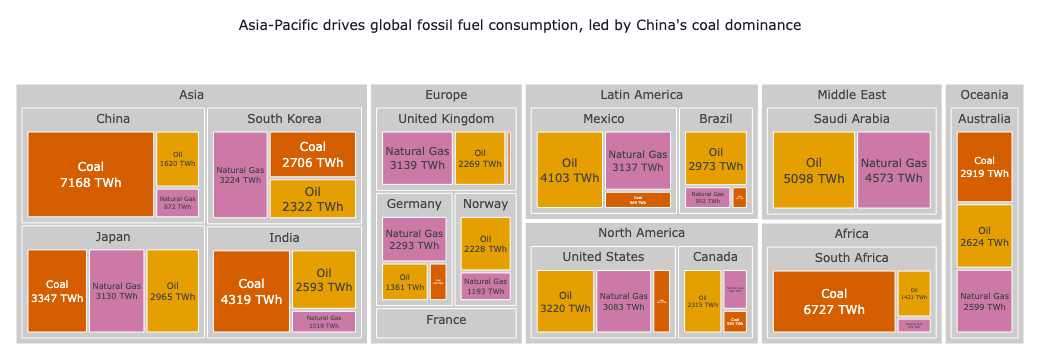

In [15]:
# Task 1 — Treemap: fossil fuel dependency by country

fossil_df = df.loc[df['Source_Type'] == 'Fossil'].copy()


fossil_colors = {
    'Coal':        '#D55E00',  
    'Oil':         '#E69F00',  
    'Natural Gas': '#CC79A7',  
}

fig1 = px.treemap(
    fossil_df,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map=fossil_colors,
    title='Asia-Pacific drives global fossil fuel consumption, led by China\'s coal dominance',
)

fig1.update_traces(
    texttemplate='%{label}<br>%{value:.0f} TWh',
    textposition='middle center',
)


fig1.data[0].marker.colors = [
    fossil_colors.get(label, '#CCCCCC')
    for label in fig1.data[0].labels
]

fig1.update_layout(
    template='plotly_white',
    title_x=0.5,
    title_font=dict(size=14, color='#1a1a2e'),
    margin=dict(t=60, l=10, r=10, b=10),
)

fig1.show()

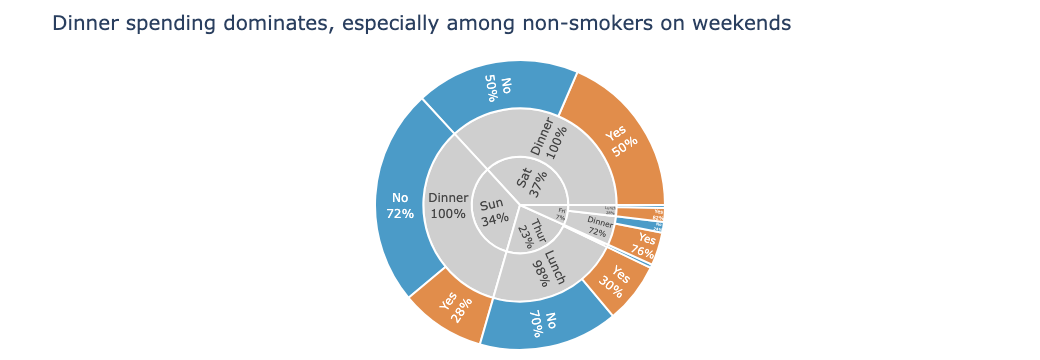

In [12]:
#task 2
import pandas as pd
import plotly.express as px

tips = px.data.tips()

tips_grouped = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
)

fig = px.sunburst(
    tips_grouped,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map={
        'Yes': '#D55E00',
        'No': '#0072B2'
    },
    title='Dinner spending dominates, especially among non-smokers on weekends'
)

fig.update_traces(
    textinfo='label+percent parent',
    insidetextorientation='radial',
    marker=dict(
        line=dict(color='white', width=2)
    ),
    root_color='#BDBDBD'
)

labels = fig.data[0].labels
parents = fig.data[0].parents

new_colors = []
for label, parent, color in zip(labels, parents, fig.data[0].marker.colors):
    if parent == "" or label in tips['day'].unique() or label in tips['time'].unique():
        new_colors.append('#CFCFCF')
    else:
        new_colors.append(color)

fig.data[0].marker.colors = new_colors

fig.update_layout(
    template='plotly_white',
    margin=dict(t=60, l=10, r=10, b=10),
    title_font_size=20
)

fig.show()

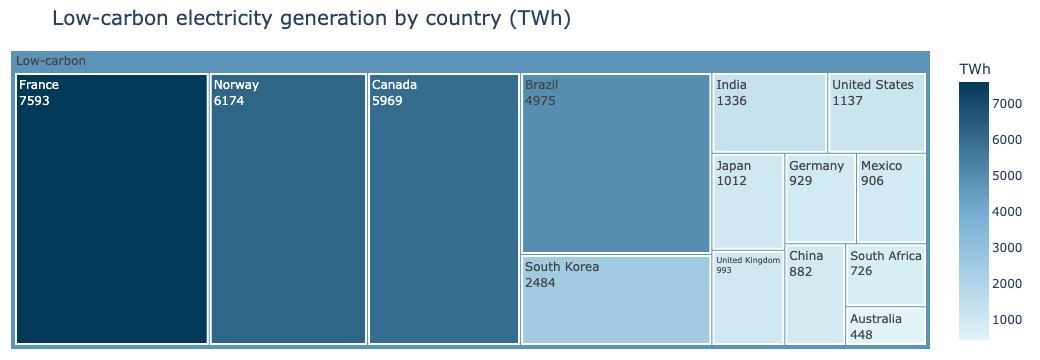

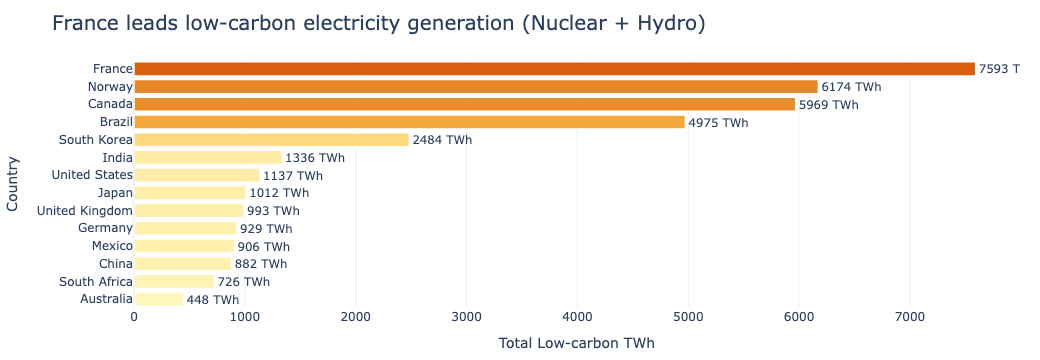

In [18]:
#task 3
import pandas as pd
import plotly.express as px

low_carbon = df[df['Source_Type'] == 'Low-carbon']

country_twh = (
    low_carbon.groupby('Country')['TWh']
    .sum()
    .reset_index()
)

country_twh['All'] = 'Low-carbon'

treemap_fig = px.treemap(
    country_twh,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale=[
        [0.0, '#E0F3F8'],
        [0.5, '#74ADD1'],
        [1.0, '#023858']
    ],
    title='Low-carbon electricity generation by country (TWh)'
)

treemap_fig.update_traces(
    textinfo='label+value',
    root_color='#D9D9D9',
    marker=dict(line=dict(color='white', width=2))
)

treemap_fig.update_layout(
    template='plotly_white',
    margin=dict(t=50, l=10, r=10, b=10),
    title_font_size=20
)

treemap_fig.show()

country_twh_sorted = country_twh.sort_values('TWh', ascending=True)

top_country = (
    country_twh.sort_values('TWh', ascending=False)
    .iloc[0]['Country']
)

bar_fig = px.bar(
    country_twh_sorted,
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale=[
        [0.0, '#FFF7BC'],
        [0.5, '#FEC44F'],
        [1.0, '#D95F0E']
    ],
    title=f'{top_country} leads low-carbon electricity generation (Nuclear + Hydro)'
)

bar_fig.update_layout(
    template='plotly_white',
    yaxis_title='Country',
    xaxis_title='Total Low-carbon TWh',
    coloraxis_showscale=False,
    title_font_size=20,
    margin=dict(t=60, l=20, r=20, b=20)
)

bar_fig.update_traces(
    texttemplate='%{x:.0f} TWh',
    textposition='outside',
    marker_line_color='white',
    marker_line_width=1.5
)

bar_fig.show()